# Stage 2 — Oracle Cross-Comparison

Joins runtime inference eval CSV against training data to answer:
- Did the model predict the correct threshold at each camera pose?
- What GPU cost did the predicted threshold produce vs the oracle-optimal threshold?
- How far was the model from optimal at each visited location?

**Join strategy**:
- `eval.cam_pos_x/y/z` → nearest neighbour to `grid_points.x/y/z` → `point_id`
- `(point_id, nearest_rot_x/y/z)` → `labels.optimal_thresholds`
- `(point_id, nearest_rot, lod_level)` → `sample_records.mean_gpu_ms`

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded OK')

Libraries loaded OK


## 1. Configuration

In [5]:
# training data folder
DATA_DIR  = Path('../../data/Baker')

# eval CSV folder
EVAL_DIR  = Path('../../data/Baker_Eval')

# frame budget for GPU cost analysis
BUDGET_MS = 3.5  # same budget used for relabeling

# max distance to accept a nearest-grid-point match (meters)
MAX_MATCH_DIST = 20.0

# rotation snap angles used during baking
BAKED_ROTATIONS = [
    (-60, 0,   -30), (-60, 0,   0), (-60, 0,   30),
    (-60, 90,  -30), (-60, 90,  0), (-60, 90,  30),
    (-60, 180, -30), (-60, 180, 0), (-60, 180, 30),
    (-60, 270, -30), (-60, 270, 0), (-60, 270, 30),
    (0,  0,   -30),  (0,  0,   0),  (0,  0,   30),
    (0,  90,  -30),  (0,  90,  0),  (0,  90,  30),
    (0,  180, -30),  (0,  180, 0),  (0,  180, 30),
    (0,  270, -30),  (0,  270, 0),  (0,  270, 30),
    (60, 0,   -30),  (60, 0,   0),  (60, 0,   30),
    (60, 90,  -30),  (60, 90,  0),  (60, 90,  30),
    (60, 180, -30),  (60, 180, 0),  (60, 180, 30),
    (60, 270, -30),  (60, 270, 0),  (60, 270, 30),
]
BAKED_ROT_ARR = np.array(BAKED_ROTATIONS, dtype=np.float32)

print(f'Data dir:  {DATA_DIR.resolve()}')
print(f'Eval dir:  {EVAL_DIR.resolve()}')

Data dir:  C:\Users\Gica\neural-lod\ml_pipeline\data\Baker
Eval dir:  C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_Eval


## 2. Load All Data

In [6]:
# training data
df_grid    = pd.read_csv(DATA_DIR / 'grid_points.csv')
df_labels  = pd.read_csv(DATA_DIR / 'labels.csv')
df_samples = pd.read_csv(DATA_DIR / 'sample_records.csv')

# eval CSVs
eval_files = list(EVAL_DIR.glob('inference_eval_*.csv'))
if not eval_files:
    raise FileNotFoundError(f'No inference_eval_*.csv in {EVAL_DIR.resolve()}')

df_eval = pd.concat([pd.read_csv(f) for f in eval_files], ignore_index=True)
df_eval = df_eval.dropna(subset=['cpu_ms','gpu_ms','fps'])

# verify eval has camera pose columns
required_cols = ['cam_pos_x','cam_pos_y','cam_pos_z','cam_rot_x','cam_rot_y','cam_rot_z']
missing = [c for c in required_cols if c not in df_eval.columns]
if missing:
    raise ValueError(f'Eval CSV is missing columns: {missing}\n'
                     f'Re-run Unity with the patched InferenceEvaluationLogger.cs')

print(f'Grid points:    {len(df_grid):,}')
print(f'Labels:         {len(df_labels):,}')
print(f'Sample records: {len(df_samples):,}')
print(f'Eval frames:    {len(df_eval):,}')
print(f'Eval runs:      {sorted(df_eval["run_label"].unique())}')

Grid points:    500
Labels:         18,000
Sample records: 72,000
Eval frames:    10,636
Eval runs:      ['neural_baker']


## 3. Spatial Join — Match Each Eval Frame to Nearest Grid Point

In [7]:
# build KD-tree on grid point XYZ coordinates
grid_xyz = df_grid[['x','y','z']].values.astype(np.float32)
grid_ids = df_grid['point_id'].values
kdtree   = cKDTree(grid_xyz)

# query nearest grid point for each eval frame
eval_xyz = df_eval[['cam_pos_x','cam_pos_y','cam_pos_z']].values.astype(np.float32)
dists, idxs = kdtree.query(eval_xyz, k=1)

df_eval = df_eval.copy()
df_eval['nearest_point_id'] = grid_ids[idxs]
df_eval['nearest_point_dist'] = dists

# filter out frames too far from any grid point
before = len(df_eval)
df_eval = df_eval[df_eval['nearest_point_dist'] <= MAX_MATCH_DIST]
after  = len(df_eval)

print(f'Frames matched to grid points: {after:,} / {before:,}')
print(f'Filtered (>{MAX_MATCH_DIST}m from any grid point): {before - after:,}')
print(f'Mean match distance: {df_eval["nearest_point_dist"].mean():.2f}m')
print(f'P95 match distance:  {df_eval["nearest_point_dist"].quantile(0.95):.2f}m')

Frames matched to grid points: 10,636 / 10,636
Filtered (>20.0m from any grid point): 0
Mean match distance: 5.82m
P95 match distance:  10.01m


## 4. Rotation Join — Match Each Eval Frame to Nearest Baked Rotation

In [8]:
def nearest_baked_rotation(rot_x, rot_y, rot_z):
    # normalize yaw to [0, 360)
    rot_y = rot_y % 360
    query = np.array([[rot_x, rot_y, rot_z]], dtype=np.float32)
    rot_tree = cKDTree(BAKED_ROT_ARR)
    _, idx = rot_tree.query(query, k=1)
    return BAKED_ROTATIONS[idx[0]]

# build rotation KD-tree once
rot_tree = cKDTree(BAKED_ROT_ARR)

eval_rots = df_eval[['cam_rot_x','cam_rot_y','cam_rot_z']].values.astype(np.float32)
# normalize yaw
eval_rots[:, 1] = eval_rots[:, 1] % 360

_, rot_idxs = rot_tree.query(eval_rots, k=1)

df_eval['nearest_rot_x'] = BAKED_ROT_ARR[rot_idxs, 0]
df_eval['nearest_rot_y'] = BAKED_ROT_ARR[rot_idxs, 1]
df_eval['nearest_rot_z'] = BAKED_ROT_ARR[rot_idxs, 2]

print('Rotation snap complete.')
print('Nearest rotation distribution:')
print(pd.Series(list(zip(df_eval['nearest_rot_x'], df_eval['nearest_rot_y']))).value_counts().head(10))

Rotation snap complete.
Nearest rotation distribution:
(0.0, 270.0)     3408
(0.0, 180.0)     2581
(0.0, 90.0)      2051
(60.0, 270.0)    1256
(0.0, 0.0)        597
(60.0, 90.0)      308
(60.0, 180.0)     270
(60.0, 0.0)       165
Name: count, dtype: int64


## 5. Oracle Label Join

In [9]:
# prepare labels for merge
df_labels_merge = df_labels.rename(columns={
    'point_id': 'nearest_point_id',
    'rot_x':    'nearest_rot_x',
    'rot_y':    'nearest_rot_y',
    'rot_z':    'nearest_rot_z',
    'optimal_thresholds': 'oracle_threshold'
})
df_labels_merge['oracle_threshold'] = pd.to_numeric(
    df_labels_merge['oracle_threshold'], errors='coerce'
)

# merge
df_joined = df_eval.merge(
    df_labels_merge[['nearest_point_id','nearest_rot_x','nearest_rot_y','nearest_rot_z','oracle_threshold']],
    on=['nearest_point_id','nearest_rot_x','nearest_rot_y','nearest_rot_z'],
    how='left'
)

matched = df_joined['oracle_threshold'].notna().sum()
print(f'Frames with oracle label matched: {matched:,} / {len(df_joined):,} ({100*matched/len(df_joined):.1f}%)')

# compute prediction error
df_joined['threshold_error']   = (df_joined['predicted_threshold'] - df_joined['oracle_threshold']).abs()
df_joined['threshold_error_signed'] = df_joined['predicted_threshold'] - df_joined['oracle_threshold']

print(f'Mean absolute threshold error: {df_joined["threshold_error"].mean():.4f}')
print(f'P95 threshold error:           {df_joined["threshold_error"].quantile(0.95):.4f}')
print(f'Mean signed error (+ = over-aggressive, - = under-aggressive):')
print(f'  {df_joined["threshold_error_signed"].mean():.4f}')

Frames with oracle label matched: 10,636 / 10,636 (100.0%)
Mean absolute threshold error: 0.2363
P95 threshold error:           0.7798
Mean signed error (+ = over-aggressive, - = under-aggressive):
  0.1202


## 6. GPU Cost Join — What Did the Predicted Threshold Actually Cost?

In [10]:
# map threshold value to LOD level
# 1.0=LOD0, 0.667=LOD1, 0.333=LOD2, 0.0=LOD3
def threshold_to_lod(t):
    if t >= 0.833:   return 0
    elif t >= 0.5:   return 1
    elif t >= 0.167: return 2
    else:            return 3

df_joined['predicted_lod'] = df_joined['predicted_threshold'].apply(threshold_to_lod)
df_joined['oracle_lod']    = df_joined['oracle_threshold'].apply(
    lambda t: threshold_to_lod(t) if pd.notna(t) else np.nan
)

# aggregate sample_records by (point_id, rot_x, rot_y, rot_z, lod_level)
df_samples_agg = df_samples.groupby(
    ['point_id','rot_x','rot_y','rot_z','lod_level']
)[['mean_gpu_ms','mean_cpu_ms']].mean().reset_index()

# join predicted LOD GPU cost
df_samples_pred = df_samples_agg.rename(columns={
    'point_id':    'nearest_point_id',
    'rot_x':       'nearest_rot_x',
    'rot_y':       'nearest_rot_y',
    'rot_z':       'nearest_rot_z',
    'lod_level':   'predicted_lod',
    'mean_gpu_ms': 'predicted_lod_gpu_ms',
    'mean_cpu_ms': 'predicted_lod_cpu_ms'
})
df_joined = df_joined.merge(df_samples_pred, on=['nearest_point_id','nearest_rot_x','nearest_rot_y','nearest_rot_z','predicted_lod'], how='left')

# join oracle LOD GPU cost
df_samples_oracle = df_samples_agg.rename(columns={
    'point_id':    'nearest_point_id',
    'rot_x':       'nearest_rot_x',
    'rot_y':       'nearest_rot_y',
    'rot_z':       'nearest_rot_z',
    'lod_level':   'oracle_lod',
    'mean_gpu_ms': 'oracle_lod_gpu_ms',
    'mean_cpu_ms': 'oracle_lod_cpu_ms'
})
df_joined = df_joined.merge(df_samples_oracle, on=['nearest_point_id','nearest_rot_x','nearest_rot_y','nearest_rot_z','oracle_lod'], how='left')

df_joined['gpu_cost_delta'] = df_joined['predicted_lod_gpu_ms'] - df_joined['oracle_lod_gpu_ms']

valid = df_joined['gpu_cost_delta'].notna()
print(f'Frames with GPU cost comparison: {valid.sum():,}')
print(f'Mean GPU cost delta (predicted - oracle): {df_joined.loc[valid, "gpu_cost_delta"].mean():.4f} ms')
print(f'  Positive = predicted used more GPU than oracle (less aggressive)')
print(f'  Negative = predicted used less GPU than oracle (more aggressive)')

Frames with GPU cost comparison: 10,636
Mean GPU cost delta (predicted - oracle): 0.4143 ms
  Positive = predicted used more GPU than oracle (less aggressive)
  Negative = predicted used less GPU than oracle (more aggressive)


## 7. Plots — Prediction Quality

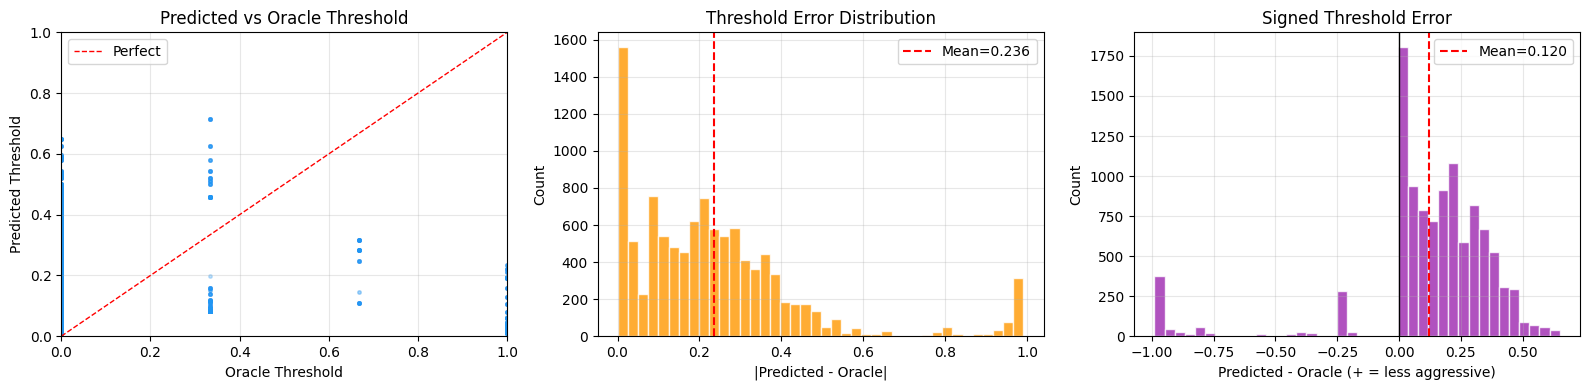

Saved: oracle_threshold_comparison.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_valid = df_joined.dropna(subset=['oracle_threshold','predicted_threshold'])

# predicted vs oracle scatter
ax = axes[0]
ax.scatter(df_valid['oracle_threshold'], df_valid['predicted_threshold'],
           alpha=0.15, s=6, c='#2196F3')
ax.plot([0,1],[0,1],'r--',linewidth=1,label='Perfect')
ax.set_xlabel('Oracle Threshold')
ax.set_ylabel('Predicted Threshold')
ax.set_title('Predicted vs Oracle Threshold')
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend(); ax.grid(True, alpha=0.3)

# threshold error distribution
ax = axes[1]
ax.hist(df_valid['threshold_error'], bins=40, color='#FF9800', alpha=0.8, edgecolor='white')
ax.axvline(df_valid['threshold_error'].mean(), color='red', linestyle='--',
           label=f'Mean={df_valid["threshold_error"].mean():.3f}')
ax.set_xlabel('|Predicted - Oracle|')
ax.set_ylabel('Count')
ax.set_title('Threshold Error Distribution')
ax.legend(); ax.grid(True, alpha=0.3)

# signed error — over/under aggressive
ax = axes[2]
ax.hist(df_valid['threshold_error_signed'], bins=40, color='#9C27B0', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(df_valid['threshold_error_signed'].mean(), color='red', linestyle='--',
           label=f'Mean={df_valid["threshold_error_signed"].mean():.3f}')
ax.set_xlabel('Predicted - Oracle (+ = less aggressive)')
ax.set_ylabel('Count')
ax.set_title('Signed Threshold Error')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('oracle_threshold_comparison.png', dpi=150)
plt.show()
print('Saved: oracle_threshold_comparison.png')

## 8. Plots — GPU Cost Impact

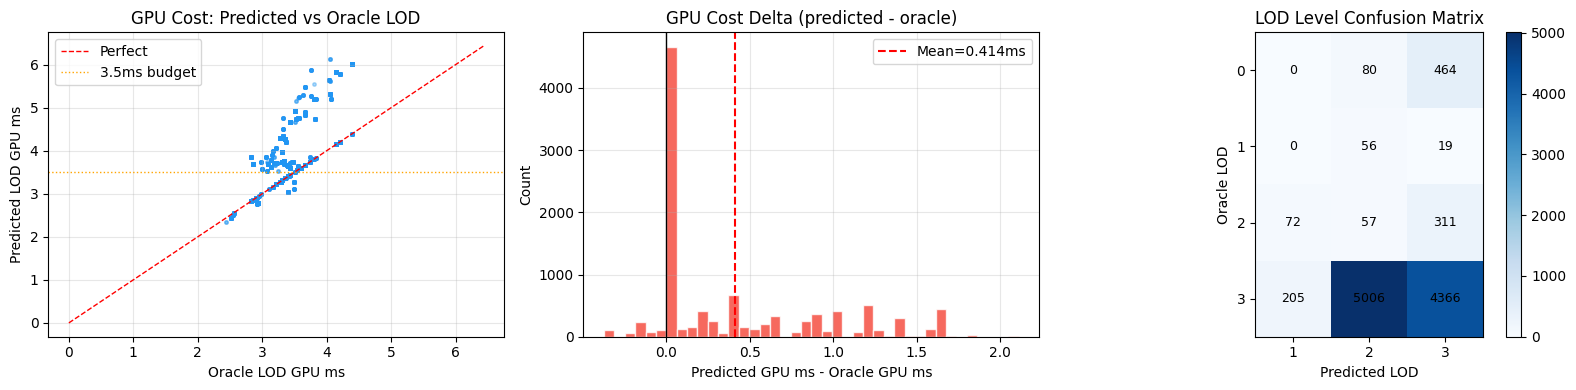

Saved: oracle_gpu_cost_comparison.png


In [12]:
df_gpu = df_joined.dropna(subset=['predicted_lod_gpu_ms','oracle_lod_gpu_ms'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# predicted vs oracle GPU cost scatter
ax = axes[0]
ax.scatter(df_gpu['oracle_lod_gpu_ms'], df_gpu['predicted_lod_gpu_ms'],
           alpha=0.2, s=6, c='#2196F3')
lim = max(df_gpu['oracle_lod_gpu_ms'].max(), df_gpu['predicted_lod_gpu_ms'].max()) * 1.05
ax.plot([0,lim],[0,lim],'r--',linewidth=1,label='Perfect')
ax.axhline(BUDGET_MS, color='orange', linestyle=':', linewidth=1, label=f'{BUDGET_MS}ms budget')
ax.set_xlabel('Oracle LOD GPU ms')
ax.set_ylabel('Predicted LOD GPU ms')
ax.set_title('GPU Cost: Predicted vs Oracle LOD')
ax.legend(); ax.grid(True, alpha=0.3)

# GPU cost delta histogram
ax = axes[1]
ax.hist(df_gpu['gpu_cost_delta'], bins=40, color='#F44336', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(df_gpu['gpu_cost_delta'].mean(), color='red', linestyle='--',
           label=f'Mean={df_gpu["gpu_cost_delta"].mean():.3f}ms')
ax.set_xlabel('Predicted GPU ms - Oracle GPU ms')
ax.set_ylabel('Count')
ax.set_title('GPU Cost Delta (predicted - oracle)')
ax.legend(); ax.grid(True, alpha=0.3)

# LOD level confusion matrix
ax = axes[2]
df_lod = df_joined.dropna(subset=['predicted_lod','oracle_lod'])
lod_levels = sorted(df_lod['oracle_lod'].unique())
confusion = pd.crosstab(df_lod['oracle_lod'].astype(int),
                         df_lod['predicted_lod'].astype(int),
                         rownames=['Oracle LOD'],
                         colnames=['Predicted LOD'])
im = ax.imshow(confusion.values, cmap='Blues')
ax.set_xticks(range(len(confusion.columns)))
ax.set_yticks(range(len(confusion.index)))
ax.set_xticklabels(confusion.columns)
ax.set_yticklabels(confusion.index)
ax.set_xlabel('Predicted LOD')
ax.set_ylabel('Oracle LOD')
ax.set_title('LOD Level Confusion Matrix')
for i in range(len(confusion.index)):
    for j in range(len(confusion.columns)):
        ax.text(j, i, str(confusion.values[i,j]), ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('oracle_gpu_cost_comparison.png', dpi=150)
plt.show()
print('Saved: oracle_gpu_cost_comparison.png')

## 9. Spatial Error Map

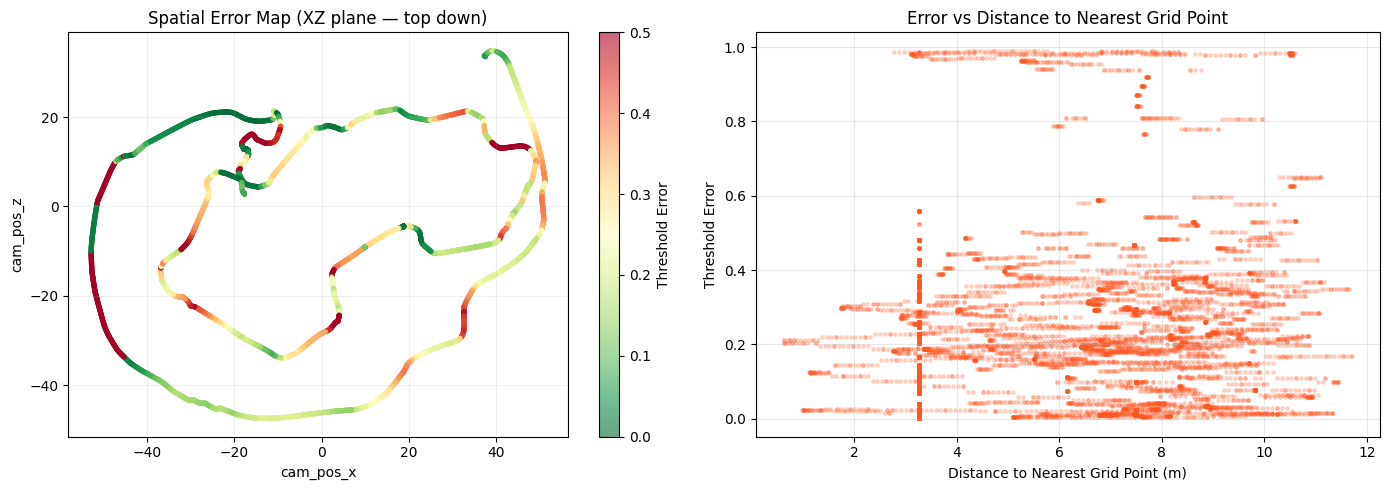

Saved: oracle_spatial_error_map.png


In [13]:
df_valid = df_joined.dropna(subset=['oracle_threshold','predicted_threshold'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XZ plane — top down
ax = axes[0]
sc = ax.scatter(df_valid['cam_pos_x'], df_valid['cam_pos_z'],
                c=df_valid['threshold_error'], cmap='RdYlGn_r',
                vmin=0, vmax=0.5, s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Threshold Error')
ax.set_xlabel('cam_pos_x')
ax.set_ylabel('cam_pos_z')
ax.set_title('Spatial Error Map (XZ plane — top down)')
ax.grid(True, alpha=0.2)

# error vs distance to nearest grid point
ax = axes[1]
ax.scatter(df_valid['nearest_point_dist'], df_valid['threshold_error'],
           alpha=0.2, s=6, c='#FF5722')
ax.set_xlabel('Distance to Nearest Grid Point (m)')
ax.set_ylabel('Threshold Error')
ax.set_title('Error vs Distance to Nearest Grid Point')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('oracle_spatial_error_map.png', dpi=150)
plt.show()
print('Saved: oracle_spatial_error_map.png')

## 10. Final Report

In [14]:
df_valid = df_joined.dropna(subset=['oracle_threshold','predicted_threshold'])
df_gpu   = df_joined.dropna(subset=['predicted_lod_gpu_ms','oracle_lod_gpu_ms'])

print('=' * 55)
print('ORACLE CROSS-COMPARISON REPORT')
print('=' * 55)
print(f'Eval frames total:              {len(df_eval):,}')
print(f'Frames matched to oracle:       {len(df_valid):,} ({100*len(df_valid)/len(df_eval):.1f}%)')
print()
print('--- Threshold Prediction Quality ---')
print(f'Mean absolute error (MAE):      {df_valid["threshold_error"].mean():.4f}')
print(f'P95 absolute error:             {df_valid["threshold_error"].quantile(0.95):.4f}')
print(f'Mean signed error:              {df_valid["threshold_error_signed"].mean():.4f}')
pct_correct_lod = 100*(df_joined.dropna(subset=["predicted_lod","oracle_lod"])
                        .eval("predicted_lod == oracle_lod").mean())
print(f'Correct LOD level predicted:    {pct_correct_lod:.1f}%')
print()
print('--- GPU Cost Impact ---')
print(f'Mean GPU cost delta:            {df_gpu["gpu_cost_delta"].mean():.4f} ms')
print(f'P95 GPU cost delta:             {df_gpu["gpu_cost_delta"].quantile(0.95):.4f} ms')
print(f'Mean oracle GPU ms:             {df_gpu["oracle_lod_gpu_ms"].mean():.4f} ms')
print(f'Mean predicted GPU ms:          {df_gpu["predicted_lod_gpu_ms"].mean():.4f} ms')
print()
print('--- Runtime Performance ---')
print(f'Mean CPU ms:                    {df_eval["cpu_ms"].mean():.3f}')
print(f'Mean GPU ms:                    {df_eval["gpu_ms"].mean():.3f}')
print(f'Mean FPS:                       {df_eval["fps"].mean():.2f}')
if 'inference_duration_ms' in df_eval.columns:
    print(f'Mean inference overhead:        {df_eval["inference_duration_ms"].mean():.4f} ms')

# save report
df_joined.to_csv('oracle_comparison_full.csv', index=False)
print()
print('Full joined data saved to: oracle_comparison_full.csv')

ORACLE CROSS-COMPARISON REPORT
Eval frames total:              10,636
Frames matched to oracle:       10,636 (100.0%)

--- Threshold Prediction Quality ---
Mean absolute error (MAE):      0.2363
P95 absolute error:             0.7798
Mean signed error:              0.1202
Correct LOD level predicted:    41.6%

--- GPU Cost Impact ---
Mean GPU cost delta:            0.4143 ms
P95 GPU cost delta:             1.6125 ms
Mean oracle GPU ms:             3.4447 ms
Mean predicted GPU ms:          3.8591 ms

--- Runtime Performance ---
Mean CPU ms:                    16.785
Mean GPU ms:                    5.094
Mean FPS:                       66.28
Mean inference overhead:        1.3470 ms

Full joined data saved to: oracle_comparison_full.csv
